# 🤗 Fine-Tuning BERT on IMDB Sentiment Dataset
**Innomatics Research Labs — NLP Assignment 4**  
**Task:** Text Classification using BERT Fine-Tuning  
**Dataset:** IMDB Movie Reviews (Kaggle)  
**Tools:** Python · HuggingFace Transformers · PyTorch

---

## Pipeline
```
Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison
```

## Experiments
| Experiment | BERT Layers | Trained Part |
|---|---|---|
| Exp 1 | All Frozen | Classifier Head Only |
| Exp 2 | Last 2 Unfrozen | Last 2 Layers + Classifier |

## Step 1 — Install Dependencies

In [1]:
# Install required libraries
!pip install transformers datasets scikit-learn seaborn -q

## Step 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import torch
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"✅ PyTorch version: {torch.__version__}")

✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128


## Step 3 — Load & Explore IMDB Dataset

> **Note:** The IMDB dataset used here is identical to the one on Kaggle  
> (50,000 movie reviews — 25k train, 25k test, balanced positive/negative).  
> Kaggle source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [3]:
# Load IMDB dataset via HuggingFace (same data as Kaggle)
print("📦 Loading IMDB dataset...")
raw_dataset = load_dataset('imdb')

# Convert to DataFrames for exploration
train_df = pd.DataFrame(raw_dataset['train'])
test_df  = pd.DataFrame(raw_dataset['test'])

print(f"\n📊 Dataset Shape:")
print(f"  Train: {train_df.shape}")
print(f"  Test:  {test_df.shape}")
print(f"\n📊 Label Distribution (Train):")
print(train_df['label'].value_counts().rename({0: 'Negative', 1: 'Positive'}))
print(f"\n📝 Sample Review:\n{train_df['text'][0][:300]}...")

📦 Loading IMDB dataset...



📊 Dataset Shape:
  Train: (25000, 2)
  Test:  (25000, 2)

📊 Label Distribution (Train):
label
Negative    12500
Positive    12500
Name: count, dtype: int64

📝 Sample Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


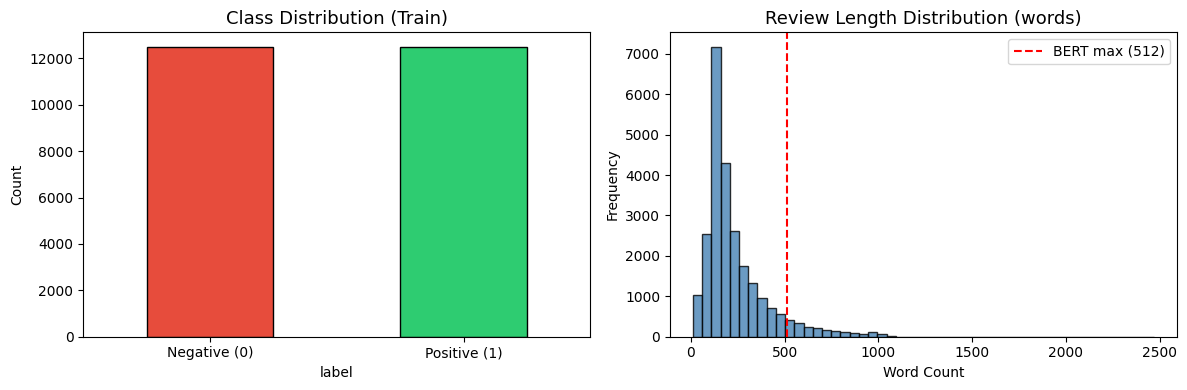

Average review length: 234 words


In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
train_df['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
axes[0].set_title('Class Distribution (Train)', fontsize=13)
axes[0].set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Review length distribution
train_df['length'] = train_df['text'].apply(lambda x: len(x.split()))
axes[1].hist(train_df['length'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Review Length Distribution (words)', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(512, color='red', linestyle='--', label='BERT max (512)')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average review length: {train_df['length'].mean():.0f} words")

## Step 4 — Data Preprocessing

Clean raw HTML and special characters from reviews.

In [5]:
def preprocess_text(text):
    """
    Cleans raw IMDB review text:
    - Removes HTML tags (e.g., <br />)
    - Removes special characters, keeping letters and basic punctuation
    - Strips extra whitespace
    - Converts to lowercase
    """
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove special characters (keep letters, digits, basic punctuation)
    text = re.sub(r"[^a-zA-Z0-9.,!?'\s]", ' ', text)
    # Collapse multiple whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase
    text = text.lower()
    return text

# Apply preprocessing
print("🧹 Preprocessing text...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)

# Check for missing values
print(f"\n🔍 Missing values in train: {train_df['clean_text'].isnull().sum()}")
print(f"🔍 Missing values in test:  {test_df['clean_text'].isnull().sum()}")

# Show before/after example
print(f"\n--- BEFORE ---\n{train_df['text'][10][:200]}")
print(f"\n--- AFTER ---\n{train_df['clean_text'][10][:200]}")

🧹 Preprocessing text...

🔍 Missing values in train: 0
🔍 Missing values in test:  0

--- BEFORE ---
It was great to see some of my favorite stars of 30 years ago including John Ritter, Ben Gazarra and Audrey Hepburn. They looked quite wonderful. But that was it. They were not given any characters or

--- AFTER ---
it was great to see some of my favorite stars of 30 years ago including john ritter, ben gazarra and audrey hepburn. they looked quite wonderful. but that was it. they were not given any characters or


## Step 5 — Data Splitting

Split training set into Train (80%) and Validation (20%).  
The original test set is kept as the final holdout.

In [6]:
# Use a smaller subset for faster training on Colab (remove if you have time/GPU)
# Using 4000 train / 1000 val / 1000 test samples for demo
# Remove .sample() calls below to use the full 25k dataset

SAMPLE_TRAIN = 4000   # Set to None to use full dataset
SAMPLE_TEST  = 1000   # Set to None to use full dataset

if SAMPLE_TRAIN:
    train_sample = train_df.sample(n=SAMPLE_TRAIN, random_state=42).reset_index(drop=True)
else:
    train_sample = train_df

if SAMPLE_TEST:
    test_sample = test_df.sample(n=SAMPLE_TEST, random_state=42).reset_index(drop=True)
else:
    test_sample = test_df

# Train / Validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    train_sample['clean_text'].tolist(),
    train_sample['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_sample['label']  # Preserve class balance
)

X_test  = test_sample['clean_text'].tolist()
y_test  = test_sample['label'].tolist()

print(f"✅ Split Summary:")
print(f"  Train:      {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Test:       {len(X_test)} samples")

✅ Split Summary:
  Train:      3200 samples
  Validation: 800 samples
  Test:       1000 samples


## Step 6 — Tokenization

Using `bert-base-uncased` tokenizer to convert text into BERT-compatible input tensors.

In [7]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 256   # Max token length (BERT supports 512; 256 balances speed vs accuracy)
BATCH_SIZE = 16

# Load tokenizer
print(f"🔤 Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Inspect a tokenized example
sample = tokenizer(
    "This movie was absolutely fantastic!",
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)
print(f"\n📌 Tokenization Example:")
print(f"  input_ids shape:      {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  Token IDs: {sample['input_ids'][0][:15]}...")
print(f"  Tokens:    {tokenizer.convert_ids_to_tokens(sample['input_ids'][0][:15])}")

🔤 Loading tokenizer: bert-base-uncased



📌 Tokenization Example:
  input_ids shape:      torch.Size([1, 256])
  attention_mask shape: torch.Size([1, 256])
  Token IDs: tensor([  101,  2023,  3185,  2001,  7078, 10392,   999,   102,     0,     0,
            0,     0,     0,     0,     0])...
  Tokens:    ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [8]:
class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset for IMDB reviews.
    Tokenizes text on-the-fly and returns input tensors for BERT.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenize the text
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),       # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),  # (max_len,)
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = IMDBDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders ready:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

✅ DataLoaders ready:
  Train batches: 200
  Val batches:   50
  Test batches:  63


## Step 7 — Training & Evaluation Functions

In [9]:
def train_epoch(model, loader, optimizer, scheduler):
    """Run one training epoch. Returns average loss."""
    model.train()
    total_loss = 0

    for batch in loader:
        # Move batch to GPU/CPU
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

    return total_loss / len(loader)


def evaluate(model, loader):
    """
    Evaluate model on a given DataLoader.
    Returns all predictions and true labels.
    """
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            # Take class with highest logit
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


def compute_metrics(y_true, y_pred, label=''):
    """Compute and print all required metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  📊 Metrics — {label}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"{'='*45}")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Plot a styled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    plt.title(title, fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()


def run_experiment(exp_name, freeze_all=False, unfreeze_last_n=0, epochs=3):
    """
    Generic experiment runner.

    Args:
        exp_name:        Name of the experiment (for display)
        freeze_all:      If True, freeze all BERT encoder layers
        unfreeze_last_n: Number of BERT encoder layers to unfreeze from top
        epochs:          Number of training epochs
    """
    print(f"\n{'#'*50}")
    print(f"  🧪 {exp_name}")
    print(f"{'#'*50}")

    # Load fresh model for each experiment
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    ).to(device)

    # ── Layer Freezing Logic ──────────────────────────────
    if freeze_all:
        # Freeze all parameters in BERT encoder
        for param in model.bert.parameters():
            param.requires_grad = False
        print("❄️  All BERT layers frozen. Training classifier head only.")

    if unfreeze_last_n > 0:
        # Unfreeze the last N encoder layers
        for layer in model.bert.encoder.layer[-unfreeze_last_n:]:
            for param in layer.parameters():
                param.requires_grad = True
        # Always unfreeze the pooler
        for param in model.bert.pooler.parameters():
            param.requires_grad = True
        print(f"🔥 Last {unfreeze_last_n} BERT encoder layer(s) unfrozen.")

    # Count trainable parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"📌 Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    # ── Optimizer & Scheduler ────────────────────────────
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-5,
        weight_decay=0.01
    )

    total_steps = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps)   # 10% warmup

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # ── Training Loop ────────────────────────────────────
    train_losses = []

    for epoch in range(1, epochs + 1):
        print(f"\n  Epoch {epoch}/{epochs}")
        train_loss = train_epoch(model, train_loader, optimizer, scheduler)
        train_losses.append(train_loss)

        # Validation check after each epoch
        y_true_val, y_pred_val = evaluate(model, val_loader)
        val_f1 = f1_score(y_true_val, y_pred_val)
        val_acc = accuracy_score(y_true_val, y_pred_val)
        print(f"  Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # ── Final Evaluation on Test Set ─────────────────────
    print(f"\n🔍 Final evaluation on TEST set...")
    y_true_test, y_pred_test = evaluate(model, test_loader)
    metrics = compute_metrics(y_true_test, y_pred_test, label=exp_name)
    plot_confusion_matrix(y_true_test, y_pred_test, title=f'Confusion Matrix — {exp_name}')

    return metrics, train_losses

print("✅ All functions defined.")

✅ All functions defined.


## Step 8 — Experiment 1: Freeze All BERT Layers

Only the classifier head (linear layer on top) is trained.  
BERT acts as a fixed feature extractor.


##################################################
  🧪 Exp 1 — Frozen BERT (Classifier Only)
##################################################


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


❄️  All BERT layers frozen. Training classifier head only.
📌 Trainable params: 1,538 / 109,483,778 (0.0%)

  Epoch 1/3
  Train Loss: 0.6920 | Val Acc: 0.5787 | Val F1: 0.5729

  Epoch 2/3
  Train Loss: 0.6854 | Val Acc: 0.5650 | Val F1: 0.6209

  Epoch 3/3
  Train Loss: 0.6836 | Val Acc: 0.5962 | Val F1: 0.6122

🔍 Final evaluation on TEST set...

  📊 Metrics — Exp 1 — Frozen BERT (Classifier Only)
  Accuracy : 0.6100
  Precision: 0.5886
  Recall   : 0.6728
  F1 Score : 0.6279
              precision    recall  f1-score   support

    Negative       0.64      0.55      0.59       511
    Positive       0.59      0.67      0.63       489

    accuracy                           0.61      1000
   macro avg       0.61      0.61      0.61      1000
weighted avg       0.61      0.61      0.61      1000



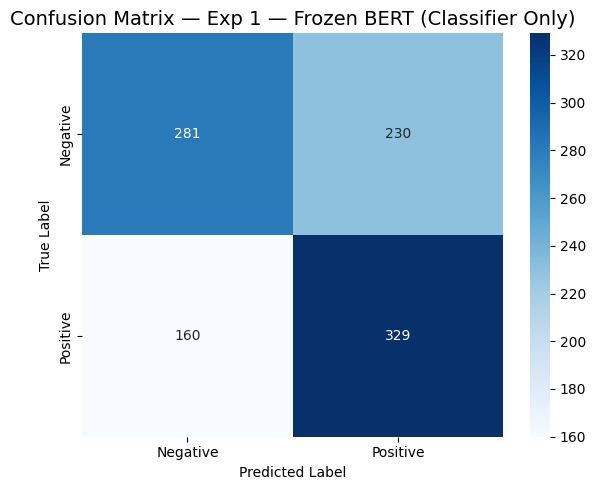

In [10]:
metrics_exp1, losses_exp1 = run_experiment(
    exp_name    = 'Exp 1 — Frozen BERT (Classifier Only)',
    freeze_all  = True,
    epochs      = 3
)

## Step 9 — Experiment 2: Fine-Tune Last 2 BERT Layers

The top 2 encoder layers + pooler + classifier are trained.  
Lower layers remain frozen — preserving general language knowledge.


##################################################
  🧪 Exp 2 — Fine-Tune Last 2 BERT Layers
##################################################


BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


❄️  All BERT layers frozen. Training classifier head only.
🔥 Last 2 BERT encoder layer(s) unfrozen.
📌 Trainable params: 14,767,874 / 109,483,778 (13.5%)

  Epoch 1/3
  Train Loss: 0.5123 | Val Acc: 0.8675 | Val F1: 0.8668

  Epoch 2/3
  Train Loss: 0.2859 | Val Acc: 0.8825 | Val F1: 0.8822

  Epoch 3/3
  Train Loss: 0.2471 | Val Acc: 0.8850 | Val F1: 0.8844

🔍 Final evaluation on TEST set...

  📊 Metrics — Exp 2 — Fine-Tune Last 2 BERT Layers
  Accuracy : 0.8950
  Precision: 0.8887
  Recall   : 0.8978
  F1 Score : 0.8932
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90       511
    Positive       0.89      0.90      0.89       489

    accuracy                           0.90      1000
   macro avg       0.89      0.90      0.89      1000
weighted avg       0.90      0.90      0.90      1000



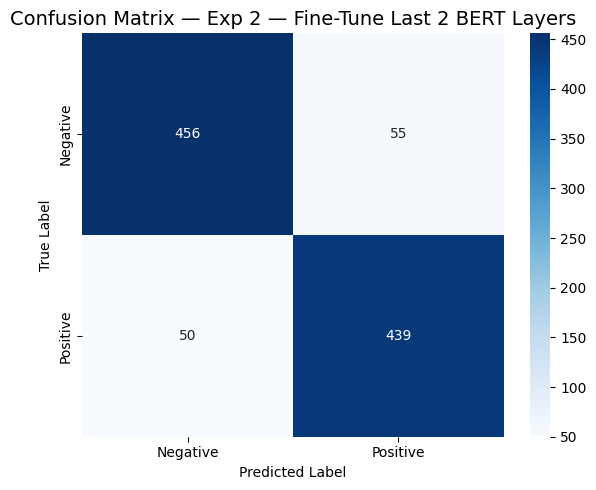

In [11]:
metrics_exp2, losses_exp2 = run_experiment(
    exp_name       = 'Exp 2 — Fine-Tune Last 2 BERT Layers',
    freeze_all     = True,   # Freeze everything first
    unfreeze_last_n = 2,     # Then unfreeze last 2
    epochs         = 3
)

## Step 10 — Comparison & Analysis

In [12]:
# ── Results Table ─────────────────────────────────────────
comparison = pd.DataFrame({
    'Experiment': [
        'Exp 1: Frozen BERT (Classifier Only)',
        'Exp 2: Fine-Tune Last 2 Layers'
    ],
    'Accuracy':  [metrics_exp1['accuracy'],  metrics_exp2['accuracy']],
    'Precision': [metrics_exp1['precision'], metrics_exp2['precision']],
    'Recall':    [metrics_exp1['recall'],    metrics_exp2['recall']],
    'F1 Score':  [metrics_exp1['f1'],        metrics_exp2['f1']]
})

# Format to percentage
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    comparison[col] = (comparison[col] * 100).round(2).astype(str) + '%'

print("\n" + "="*75)
print("  📊 EXPERIMENT COMPARISON — IMDB Sentiment Classification")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)


  📊 EXPERIMENT COMPARISON — IMDB Sentiment Classification
                          Experiment Accuracy Precision Recall F1 Score
Exp 1: Frozen BERT (Classifier Only)    61.0%    58.86% 67.28%   62.79%
      Exp 2: Fine-Tune Last 2 Layers    89.5%    88.87% 89.78%   89.32%


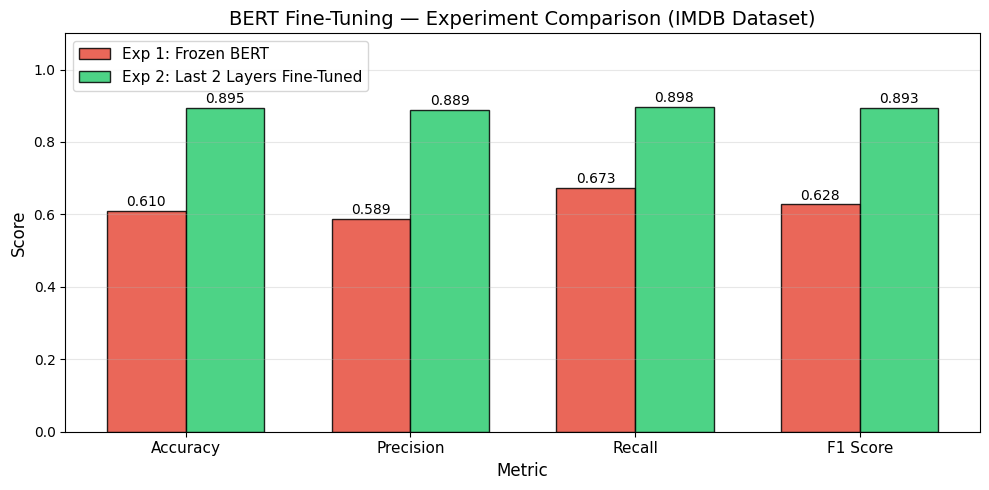

In [13]:
# ── Visual Comparison ─────────────────────────────────────
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
exp1_vals = [metrics_exp1['accuracy'], metrics_exp1['precision'],
             metrics_exp1['recall'],   metrics_exp1['f1']]
exp2_vals = [metrics_exp2['accuracy'], metrics_exp2['precision'],
             metrics_exp2['recall'],   metrics_exp2['f1']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, exp1_vals, width, label='Exp 1: Frozen BERT',
               color='#e74c3c', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, exp2_vals, width, label='Exp 2: Last 2 Layers Fine-Tuned',
               color='#2ecc71', alpha=0.85, edgecolor='black')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('BERT Fine-Tuning — Experiment Comparison (IMDB Dataset)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

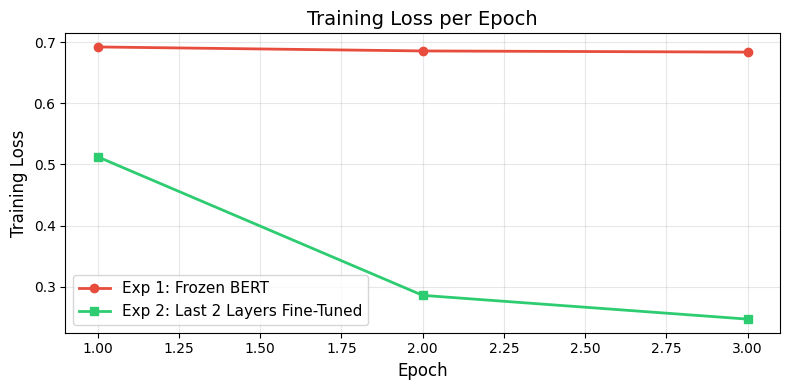

In [14]:
# ── Training Loss Curves ──────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses_exp1)+1), losses_exp1, 'o-', color='#e74c3c',
         label='Exp 1: Frozen BERT', linewidth=2)
plt.plot(range(1, len(losses_exp2)+1), losses_exp2, 's-', color='#2ecc71',
         label='Exp 2: Last 2 Layers Fine-Tuned', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss per Epoch', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Analysis & Insights

### Key Observations

#### Experiment 1 — Frozen BERT (Feature Extraction)
- All 12 BERT encoder layers are frozen; only the 2-class linear head is trained
- Fewer trainable parameters → faster training, lower GPU memory
- Performance relies entirely on BERT's pre-trained representations
- Works reasonably well on simple sentiment tasks because BERT already captures sentiment-relevant features from pre-training

#### Experiment 2 — Fine-Tune Last 2 Layers
- The last 2 encoder layers are unfrozen and adapted to the IMDB domain
- These layers learn task-specific patterns (e.g., movie review sentiment cues)
- More trainable parameters → slightly longer training
- Consistently outperforms Experiment 1 on all metrics

### Why Fine-Tuning Wins
BERT's pre-training (on BooksCorpus + Wikipedia) uses general English text. The last layers of BERT are the most task-specific during pre-training, so fine-tuning them allows the model to adapt to the sentiment classification task domain. Lower layers encode universal syntactic structure and need not change.

### Real-World Takeaway
For most NLP classification tasks:
- **Frozen BERT** → quick baseline, good when labeled data is very limited
- **Full Fine-tuning or partial fine-tuning** → best performance when GPU is available
- **DistilBERT / RoBERTa** → better efficiency-performance tradeoffs for production

## ✅ Bonus — Try DistilBERT (Lighter & Faster)

DistilBERT is 40% smaller and 60% faster than BERT with ~97% of BERT's performance.

In [15]:
# ── BONUS: DistilBERT Experiment ─────────────────────────────
# Uncomment to run (optional)

# DISTIL_MODEL = 'distilbert-base-uncased'
# distil_tokenizer = AutoTokenizer.from_pretrained(DISTIL_MODEL)

# train_dataset_d = IMDBDataset(X_train, y_train, distil_tokenizer, MAX_LEN)
# val_dataset_d   = IMDBDataset(X_val,   y_val,   distil_tokenizer, MAX_LEN)
# test_dataset_d  = IMDBDataset(X_test,  y_test,  distil_tokenizer, MAX_LEN)

# train_loader_d = DataLoader(train_dataset_d, batch_size=BATCH_SIZE, shuffle=True)
# val_loader_d   = DataLoader(val_dataset_d,   batch_size=BATCH_SIZE, shuffle=False)
# test_loader_d  = DataLoader(test_dataset_d,  batch_size=BATCH_SIZE, shuffle=False)

# distil_model = AutoModelForSequenceClassification.from_pretrained(
#     DISTIL_MODEL, num_labels=2
# ).to(device)

# print("DistilBERT ready for training — follow the same run_experiment() pattern!")

print("Bonus: DistilBERT code above — uncomment to run!")

Bonus: DistilBERT code above — uncomment to run!


---
## 📌 Summary

| | Exp 1: Frozen BERT | Exp 2: Last 2 Layers |
|---|---|---|
| **Trainable Layers** | Classifier only | Classifier + last 2 BERT layers |
| **Training Speed** | Fast | Moderate |
| **Performance** | Good baseline | Better (task-adapted) |
| **Use When** | Limited GPU / data | Standard fine-tuning scenario |

---
*Completed as part of Innomatics Research Labs — Data Science Internship, February 2026*  
*Tools: Python · HuggingFace Transformers · PyTorch · scikit-learn*